# Milos — farmer WSP + replan Gantt

Self-contained under `milos/` (no `agent/`). Primary plots are **farmer-only** (5 tiles).

Optional: smoke `[wsp_plan]` lines from the live agent are filtered to zone I (`t1`–`t5`) so you can compare day-0 / replan for the farmer snake only — not full TwoLand.


In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "main.py").exists() and not (ROOT / "milos").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline

from milos.wsp import (
    FARMER_TILES_FIVE,
    accumulate_absolute,
    load_wsp_plans,
    plot_plan,
    plot_zone_ops_replans,
    solve,
)

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())


/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


## Farmer-only WSP (`milos.wsp.solve`)

Day-0 uses `milos/wsp/prestart.json` when horizon=30 and all 5 tiles empty; otherwise runs the local MIP.


[milos/wsp] farmer prestart loaded tiles=5 from prestart.json complete=True
complete True tiles [0, 1, 2, 3, 4]


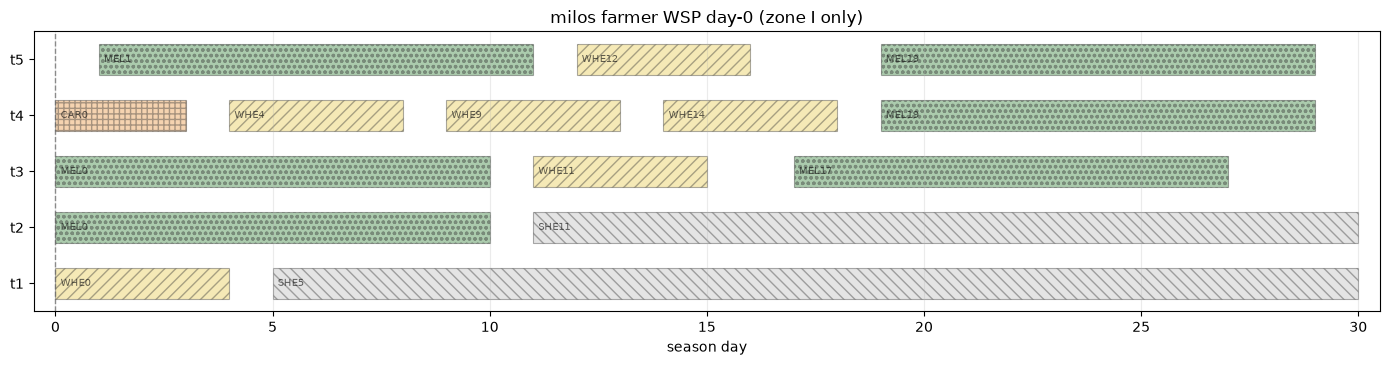

In [8]:
from milos.wsp import data as wsp_data

i0 = wsp_data.i0_base_prices()
price_of = lambda p, _i0=i0: _i0[p]

empty = list(FARMER_TILES_FIVE)
result = solve(
    [],
    horizon=30,
    empty_tiles=empty,
    empty_counts={"farmer": len(empty)},
    starting_money=3000,
    price_of=price_of,
)
print("complete", result.complete, "tiles", sorted(result.assigned))
plot_plan(
    result.assigned,
    replan_day=0,
    horizon=30,
    title="milos farmer WSP day-0 (zone I only)",
)


## Smoke log — full farmer Gantt per replan

Accumulate `[wsp_plan]` deltas onto the day-0 farmer board, then plot the **full** zone-I Gantt: past α=0.3, unchanged future α=0.6, **this replan's tiles α=1.0**.


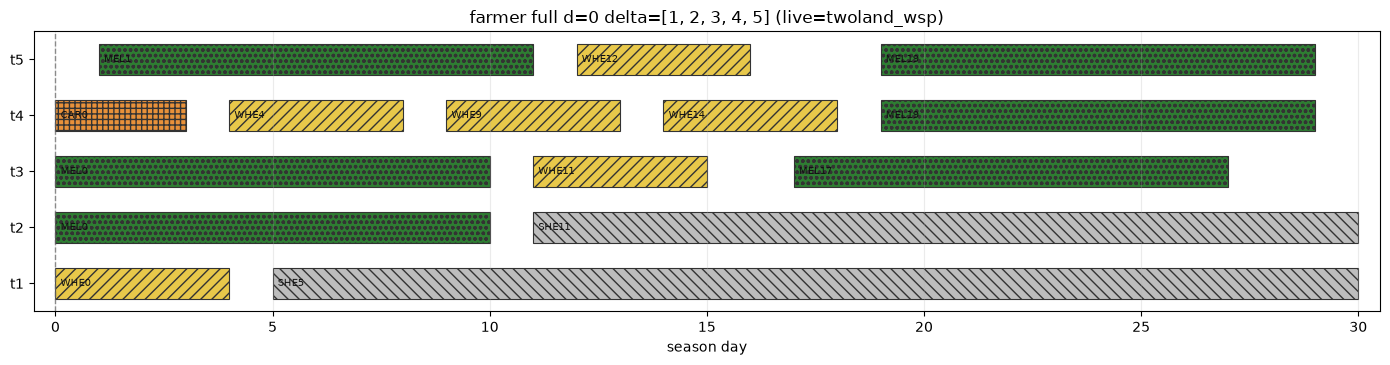

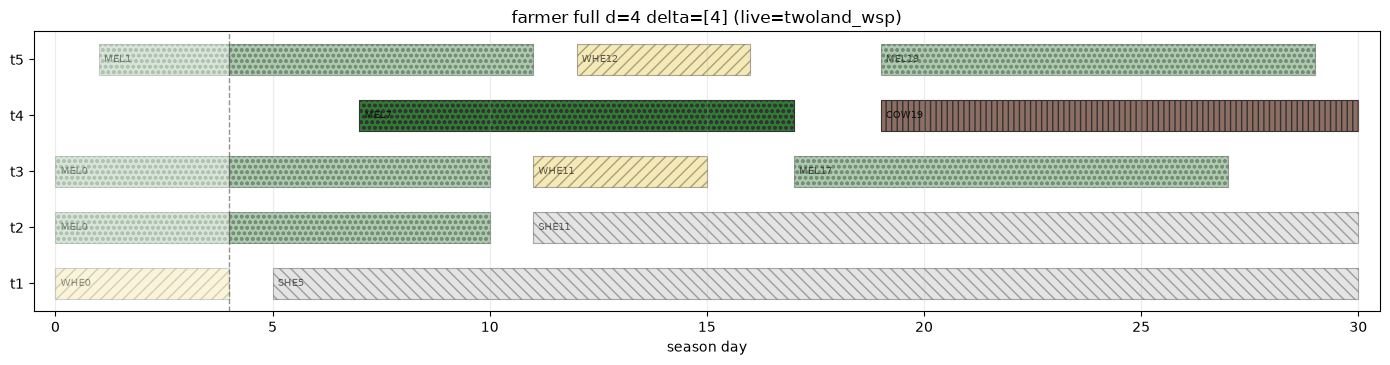

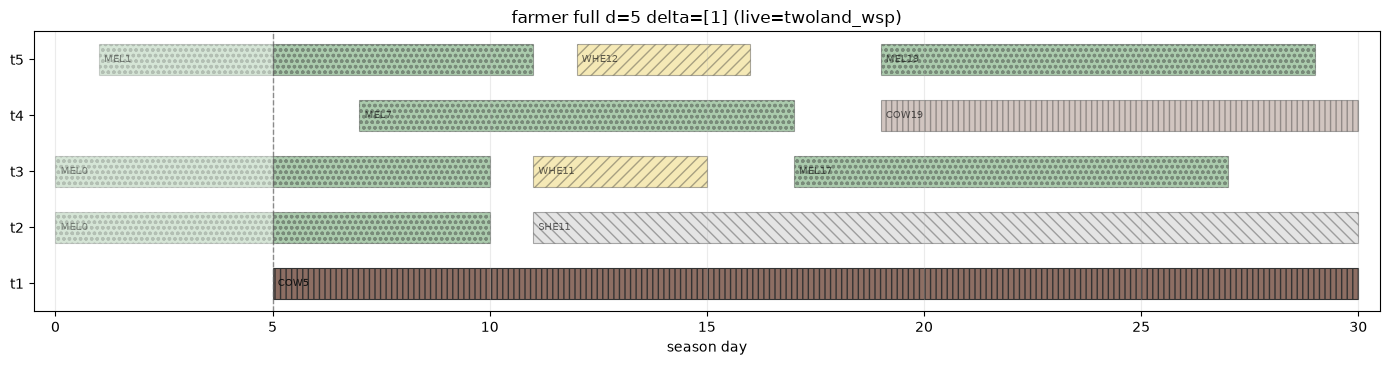

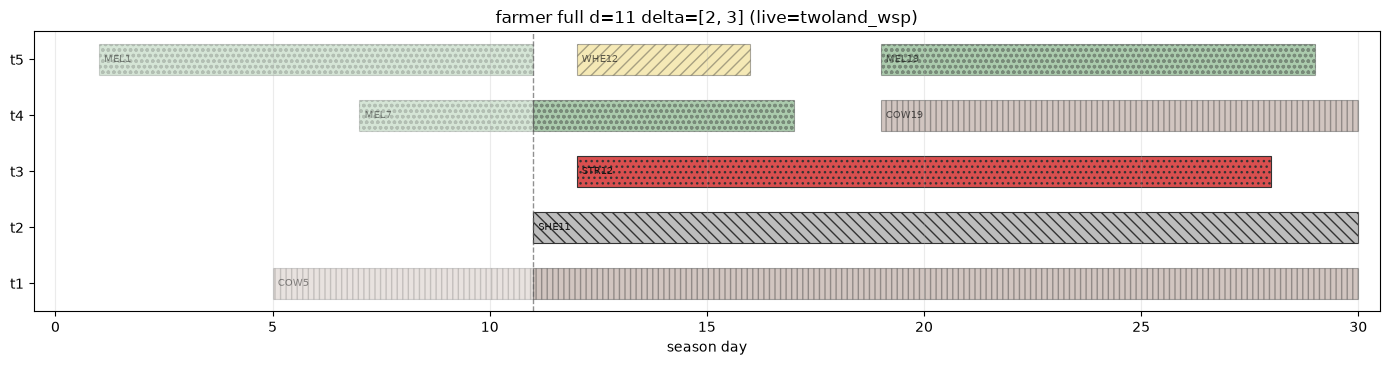

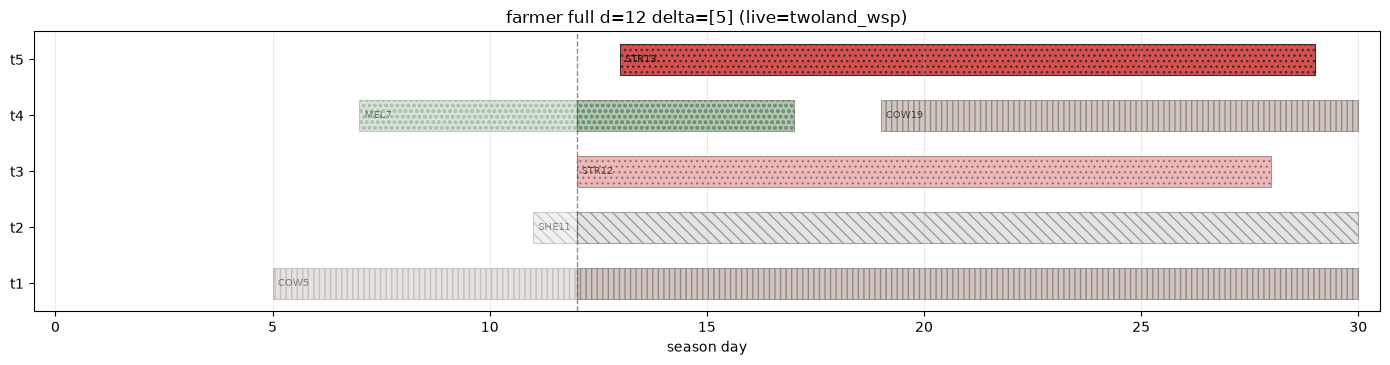

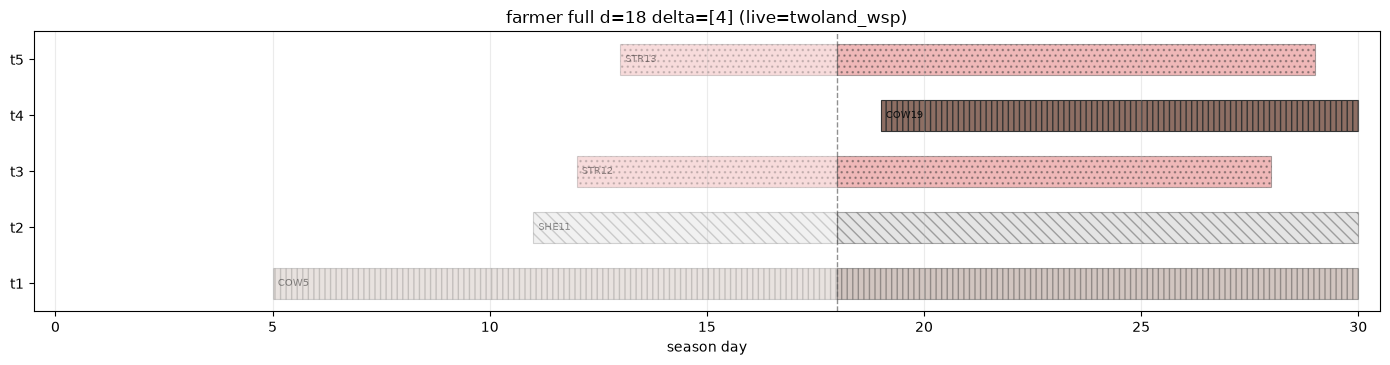

plotted 6/23 snapshots (skipped empty farmer deltas)


In [9]:
farmer_set = set(FARMER_TILES_FIVE)
plans = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
snaps = accumulate_absolute(plans, tiles=farmer_set)
plotted = 0
for plan, assigned, delta in snaps:
    if not delta:
        continue
    plotted += 1
    plot_plan(
        assigned,
        replan_day=plan.day,
        horizon=plan.horizon,
        now=plan.day,
        absolute=True,
        delta_tiles=delta,
        title=f"farmer full d={plan.day} delta={sorted(t+1 for t in delta)} (live={plan.solver})",
    )
print(f"plotted {plotted}/{len(snaps)} snapshots (skipped empty farmer deltas)")


## Farmer OPS by replan

Same smoke `[wsp_plan]` stream as the Gantt (live **TwoLand** agent), but **farmer / zone I only** (`t1`–`t5`). One **line + dots** per replan: total planned `daily_tile_ops` from that replan day to season end. Color = replan index (`turbo`; colorbar = replan day).


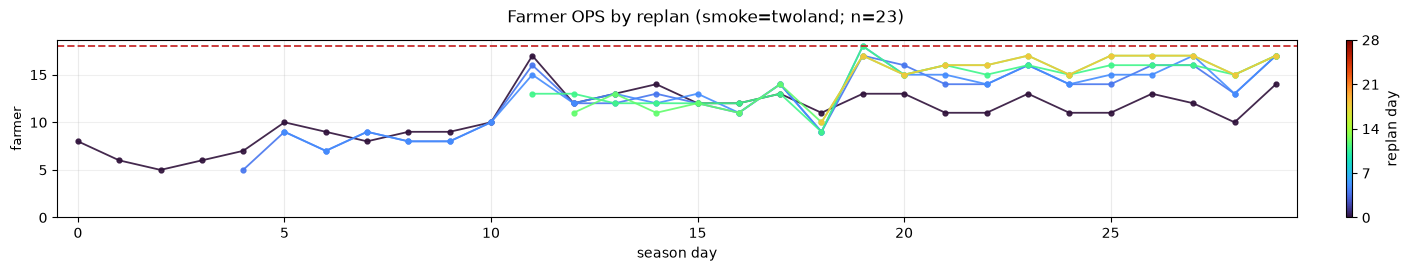

In [11]:
farmer_set = set(FARMER_TILES_FIVE)
plans_farmer = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
plot_zone_ops_replans(
    plans_farmer,
    {"farmer": farmer_set},
    # net_tile_ops=18 auto for farmer; colorbar fixed 0..28
    title=f"Farmer OPS by replan (smoke=twoland; n={len(plans_farmer)})",
)